In [27]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl

In [36]:
def ones_cube(n: int, dtype=int):
    """
    Return an (n, n, n) NumPy array filled with 1s.
    """
    if not isinstance(n, int) or n < 0:
        raise ValueError("n must be a non-negative integer")
    return np.ones((n, n, n), dtype=dtype)


cube = ones_cube(8)

cube[4,4:6] = 0
cube[2,1:4] = 0
cube[:,5,6:7] = 0
cube[4:6,:,1] = 0

inverse_cube = np.logical_not(cube)

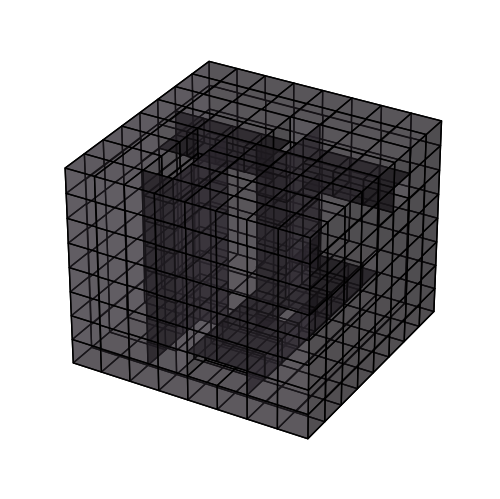

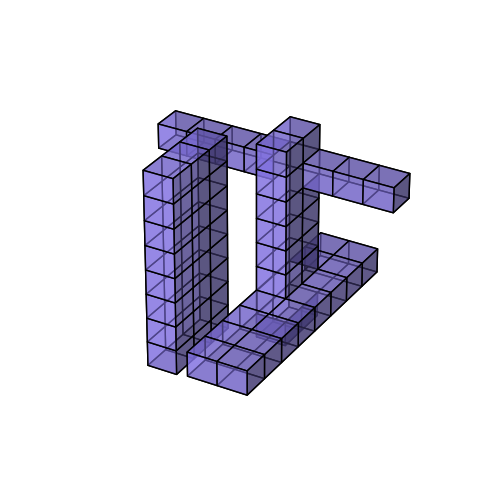

(<Figure size 640x480 with 1 Axes>, <Axes3DSubplot: >)

In [ ]:
from matplotlib.colors import to_rgba

def plot_binary_cube(cube: np.ndarray, hex_color: str = '#1f77b4', alpha: float = 0.7, edgecolor: str = 'k',save_path = None):
    """
    Plot a 3D voxel cube for binary data (0/1 or bool).
      - 0 => transparent
      - 1 => colored with hex_color and given alpha
    """
    if cube.ndim != 3:
        raise ValueError("cube must be a 3D array")

    # Accept bool or any numeric type but require only {0,1}
    data = np.asarray(cube)
    if data.dtype == np.bool_:
        filled = data
    else:
        # Convert to integers and validate values
        data = data.astype(np.int8, copy=False)
        unique_vals = np.unique(data)
        if not np.all(np.isin(unique_vals, [0, 1])):
            raise ValueError("cube must contain only 0 and 1 values")
        filled = data.astype(bool, copy=False)

    if not filled.any():
        raise ValueError("cube has no 1-voxels to display")

    # Prepare facecolors RGBA array
    rgba = list(to_rgba(hex_color, alpha=alpha))
    facecolors = np.zeros(filled.shape + (4,), dtype=float)
    facecolors[filled] = rgba
    facecolors[~filled, 3] = 0.0  # transparent for zeros

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.voxels(filled, facecolors=facecolors, edgecolor=edgecolor)
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    if save_path is not None:
        plt.savefig(save_path, format='png', bbox_inches='tight', pad_inches=0)
    plt.show()
    return fig, ax

folder = '\\192.168.10.106\imdea\DataDriven_UT_AlbertoVicente\01_Documentation\08_conferences\EUROMAT 2025\figures'

# Examples:
plot_binary_cube(cube, hex_color='#342E37', alpha=0.5,save_path=folder+'\volume.png')
plot_binary_cube(inverse_cube, hex_color='#9381FF', alpha=0.6,save_path=folder+'\void.png')